# Data Collection and Analysis
The first step in our project is to collect the necessary data for training and evaluating our seizure detection models. We will use the "Epileptic Seizure Recognition" dataset, which contains EEG recordings from 23 patients (and ocassionally other signals that we will exclude from analysis). Each recording is labeled as either normal or status epilepticus, providing a basis for training and evaluating classification models. We will download the relevant files, including the summary files for each patient and the `SUBJECT-INFO.txt` file, which contains demographic and clinical information about the patients. This data will be essential for understanding the characteristics of the recordings and for selecting appropriate subsets for analysis.

In [6]:
import os
from pathlib import Path
cur_dir = Path(os.getcwd())
proj_dir = cur_dir.resolve().parent.parent
RAW_INFO_PATH = proj_dir / "data" / "raw" / "info"
RAW_RECORDS_PATH = proj_dir / "data" / "raw" / "records"

from utils.collection.collect import *
from utils.exploration.raw_data import *

## Data Information Retrieval
We retrieve the dataset information using the `SUBJECT-INFO.txt` file and the summary files for each patient. This information is organized into a DataFrame for easier analysis and visualization. We will analyze the distribution of seizures across patients, the duration of seizures, and other relevant clinical information to inform our data selection process.

In [7]:
collect_info(RAW_INFO_PATH)

[-] Target directory: C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\data\raw\info
[-] Downloading SUBJECT-INFO...
Finished downloading files
[-] Fetching record list from PhysioNet...
[-] Downloading 24 summary files...
Finished downloading files

[OK] Download completed successfully in: C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\data\raw\info


In [8]:
df_info = make_info_df(RAW_INFO_PATH, save_csv=True, csv_path = RAW_INFO_PATH/"collected_info.csv")
df_info.head()

[OK] DataFrame saved to C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\data\raw\info\collected_info.csv


,Subject,Sampling_Freq,Num_Seizures,Seizure_Durations,Avg_Seizure_Dur,Min_Seizure_Dur,Max_Seizure_Dur,Num_Files,Sex,Age
0,chb01,256,7,"[40, 27, 40, 51, 90, 93, 101]",63.142857,27,101,42,F,11
1,chb02,256,3,"[82, 81, 9]",57.333333,9,82,36,M,11
2,chb03,256,7,"[52, 65, 69, 52, 47, 64, 53]",57.428571,47,69,38,F,14
3,chb04,256,4,"[49, 111, 102, 116]",94.500000,49,116,42,M,22
4,chb05,256,5,"[115, 110, 96, 120, 117]",111.600000,96,120,39,F,7


In [9]:
df_info

,Subject,Sampling_Freq,Num_Seizures,Seizure_Durations,Avg_Seizure_Dur,Min_Seizure_Dur,Max_Seizure_Dur,Num_Files,Sex,Age
0,chb01,256,7,"[40, 27, 40, 51, 90, 93, 101]",63.142857,27,101,42,F,11
1,chb02,256,3,"[82, 81, 9]",57.333333,9,82,36,M,11
2,chb03,256,7,"[52, 65, 69, 52, 47, 64, 53]",57.428571,47,69,38,F,14
3,chb04,256,4,"[49, 111, 102, 116]",94.500000,49,116,42,M,22
4,chb05,256,5,"[115, 110, 96, 120, 117]",111.600000,96,120,39,F,7
5,chb06,256,10,"[14, 15, 15, 20, 20, 16, 12, 13, 12, 16]",15.300000,12,20,18,F,1.5
6,chb07,256,3,"[86, 96, 143]",108.333333,86,143,19,F,14.5
7,chb08,256,5,"[171, 190, 134, 160, 264]",183.800000,134,264,20,M,3.5
8,chb09,256,4,"[64, 79, 71, 62]",69.000000,62,79,19,F,10
9,chb10,256,7,"[35, 70, 65, 58, 76, 89, 54]",63.857143,35,89,25,M,3


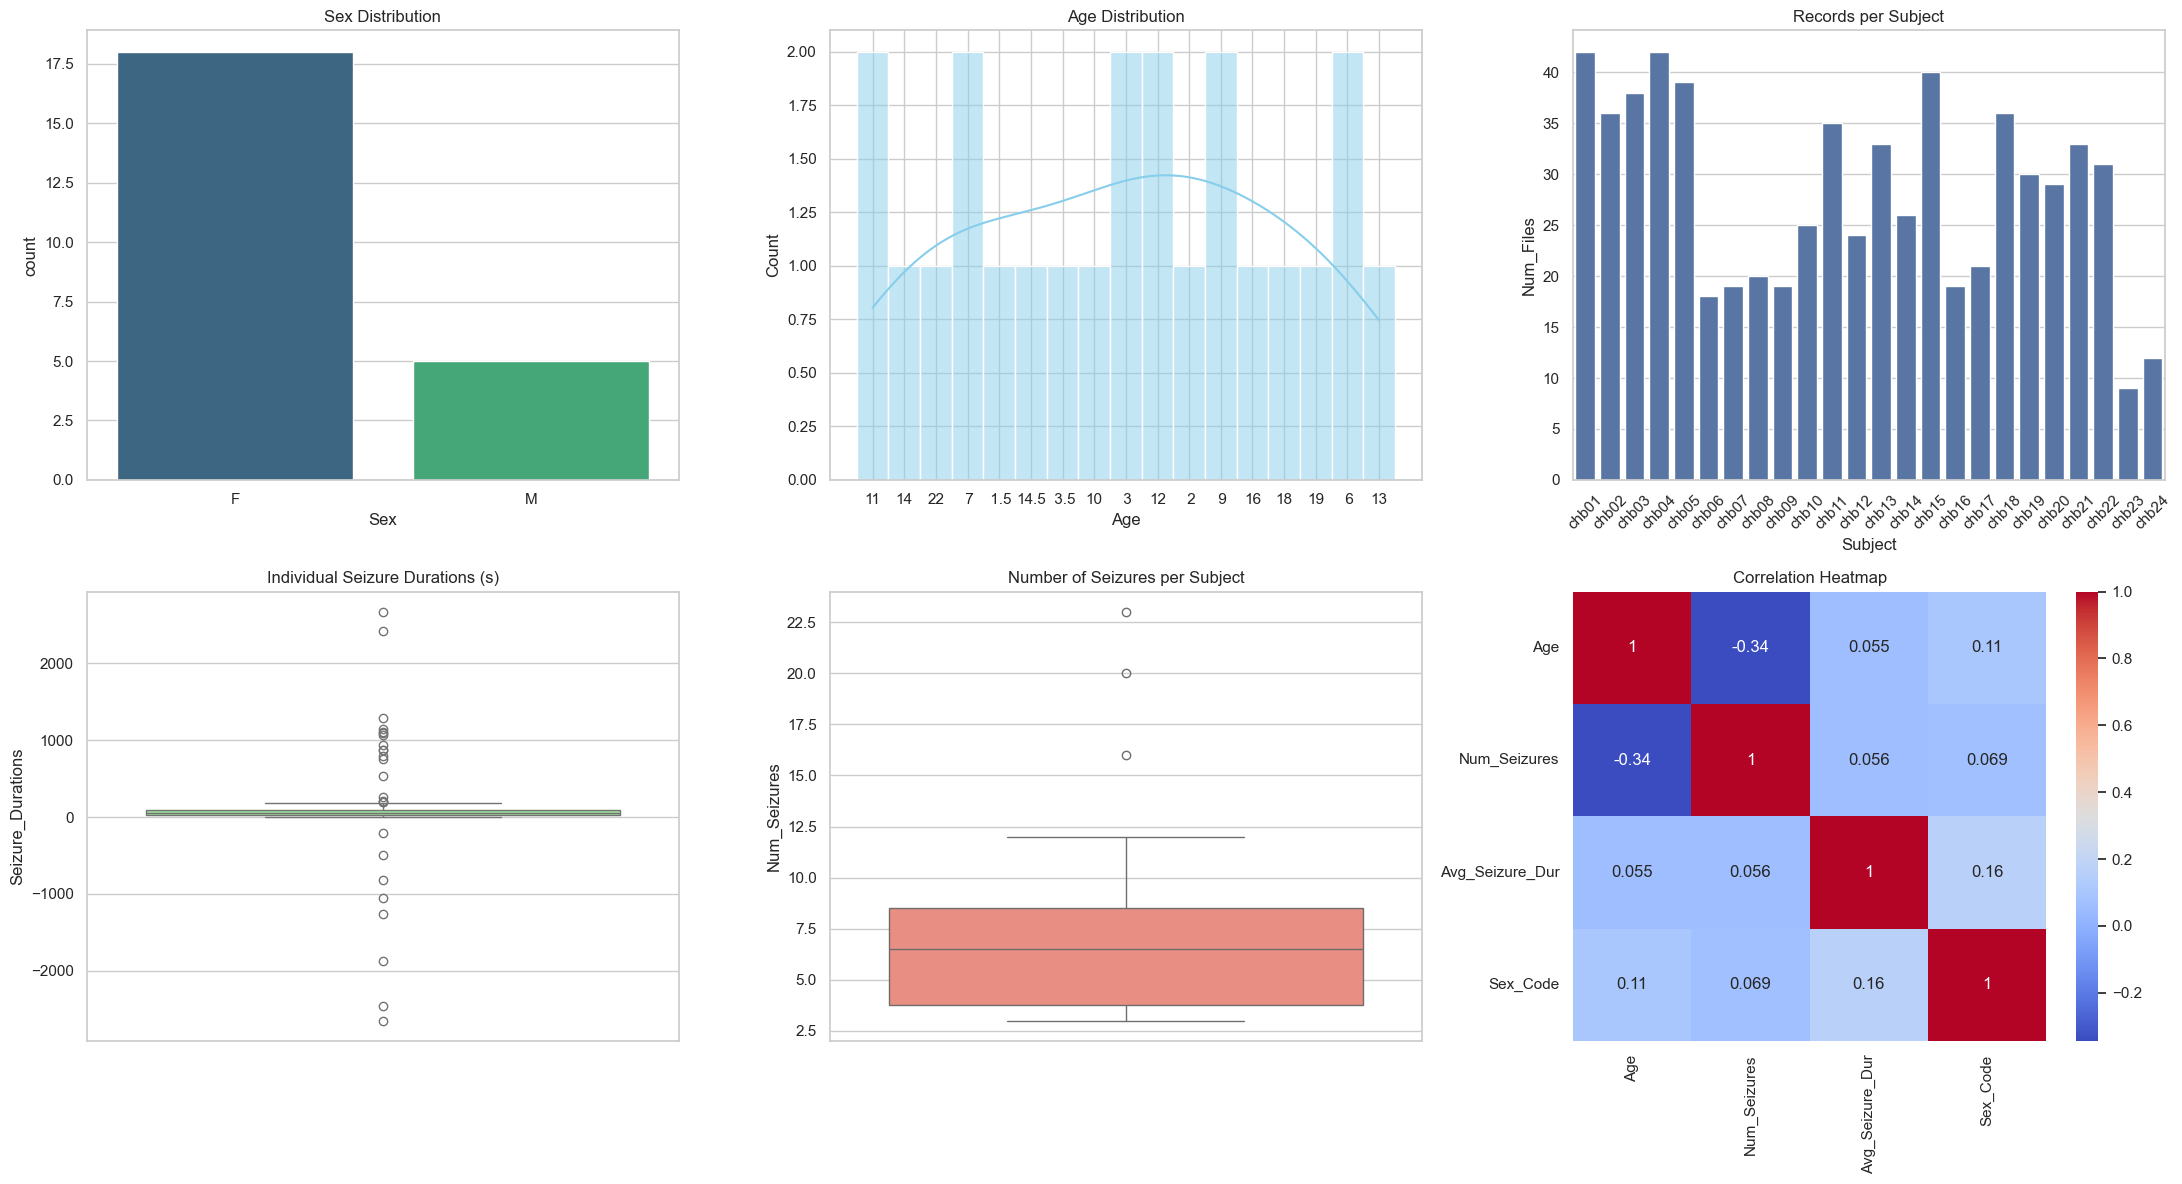

In [10]:
show_info(df_info)

> The dataset is quite biased, with more males than females subjects, and the age distribution is quite the same, we've about 1/2 subjects for each age, covering an age range from 1.5 to 22 years old. The seizure duration present a lot of outliers between all the patients, even if all the patients have a median seizure duration of around 20 seconds, some patients have seizures that last more than 100 seconds, and some even more than 200 seconds. The number of seizures per patient is quite constant, with a median of around 6 seizures per patient, but some patients have more than 20 seizures, and some even more than 40 seizures.

## Record Retrieval and Selection
Instead of using the whole dataset, we select specific patients based on the meta-analysis. For each patient, we keep all files containing seizures and a subset of seizure-free files (maintaining a specific ratio where non-seizure time is greater than seizure time). This selection contains both seizure and non-seizure data, which is crucial for training effective classification models. The selected records are organized and stored in a structured format for subsequent preprocessing and analysis steps.

In [13]:
patient_ids_selected = [4, 13, 19, 12]

In [14]:
for patient_id in patient_ids_selected:
    collect_rec_of(patient_id, non_seizure_limit=0)
    print()

[-] Patient chb04: Found 3 seizure files and 39 normal files.
[-] Selected 3 files for download (Limit non-seizure: 0).
[!] File chb04_05.edf already exists. Skipping...
[!] File chb04_08.edf already exists. Skipping...
[!] File chb04_28.edf already exists. Skipping...

[-] Patient chb13: Found 8 seizure files and 25 normal files.
[-] Selected 8 files for download (Limit non-seizure: 0).
[!] File chb13_19.edf already exists. Skipping...
[!] File chb13_21.edf already exists. Skipping...
[!] File chb13_40.edf already exists. Skipping...
[!] File chb13_55.edf already exists. Skipping...
[!] File chb13_58.edf already exists. Skipping...
[!] File chb13_59.edf already exists. Skipping...
[!] File chb13_60.edf already exists. Skipping...
[!] File chb13_62.edf already exists. Skipping...

[-] Patient chb19: Found 3 seizure files and 27 normal files.
[-] Selected 3 files for download (Limit non-seizure: 0).
[!] File chb19_28.edf already exists. Skipping...
[!] File chb19_29.edf already exists. 

> Since the collection of data from the server and we've only two weeks to complete the project, we decided to select a random patient and start working on it, creating suited models for him prediction.